In [1]:
import sys
import pickle,itertools
import copy
import os

import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mplcolors
from matplotlib.gridspec import GridSpec

import pypsa
import cartopy.crs as ccrs 
import cartopy
import cartopy.geodesic as gd
from shapely.geometry import Point


from tqdm import tqdm


path = '/media/fkaiser/'

save_path = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/'

path_to_pypsa_network   = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/'
results_path = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/Results/'

sys.path.append(path+'Code/power-system-split/power_system_split/')
import utils,visualisation

/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/xarray/backends/cfgrib_.py:27: UserWarning: Failed to load cfgrib - most likely there is a problem accessing the ecCodes library. Try `import cfgrib` to get the full error message
  warnings.warn(


In [2]:
### Colors for plotting taken from Pypsa
colors = {
    "onwind" : "#235ebc",
    'offwind' : "#6895dd",
    'offwind-ac' : "#6895dd",
    'offwind-dc' : "#74c6f2",
    "ror" : "#4adbc8",
    'solar' : "#f9d002",
    "OCGT" : "#d35050",
    "CCGT" : "#b20101",
    "Nuclear" : "#ff9000",
    "nuclear" : "#ff9000",
    "coal" : "#707070",
    "lignite" : "#9e5a01",
    "biomass" : '#0c6013',
    'geothermal' : '#ba91b1',
    "oil" : "#262626"}

# Figure 2

In [3]:
co2ls = np.arange(0.0,0.99,0.05)

carrier_types = ['CCGT', 'OCGT', 'biomass', 'coal', 'geothermal', 'lignite', 'nuclear',
                 'offwind-ac', 'offwind-dc', 'oil', 'onwind', 'ror', 'solar'],
generation_by_carrier_and_co2l = pd.DataFrame(index = pd.Index(*carrier_types),
                                   columns = ['{0:.2f}'.format(co2l) for i,co2l in enumerate(co2ls)])

for i,level in enumerate(co2ls):
    n = pypsa.Network()
    co2lstr = '{0:.2f}'.format(level)
    level = np.round(level,2)
    n.import_from_netcdf(path_to_pypsa_network+f'elec_s_800_ec_lv1.0_Co2L{level}-3H.nc')
    generation_by_carrier_and_co2l[co2lstr] = n.generators_t.p.T.groupby(n.generators["carrier"]).sum().sum(axis=1)

/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/xarray/backends/plugins.py:61: RuntimeWarning: Engine 'cfgrib' loading failed:
Cannot find the ecCodes library
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.0-3H.nc has buses, car

INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.45-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.5-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
/home/fkaiser/.conda/env

INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.95-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.95-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this wi

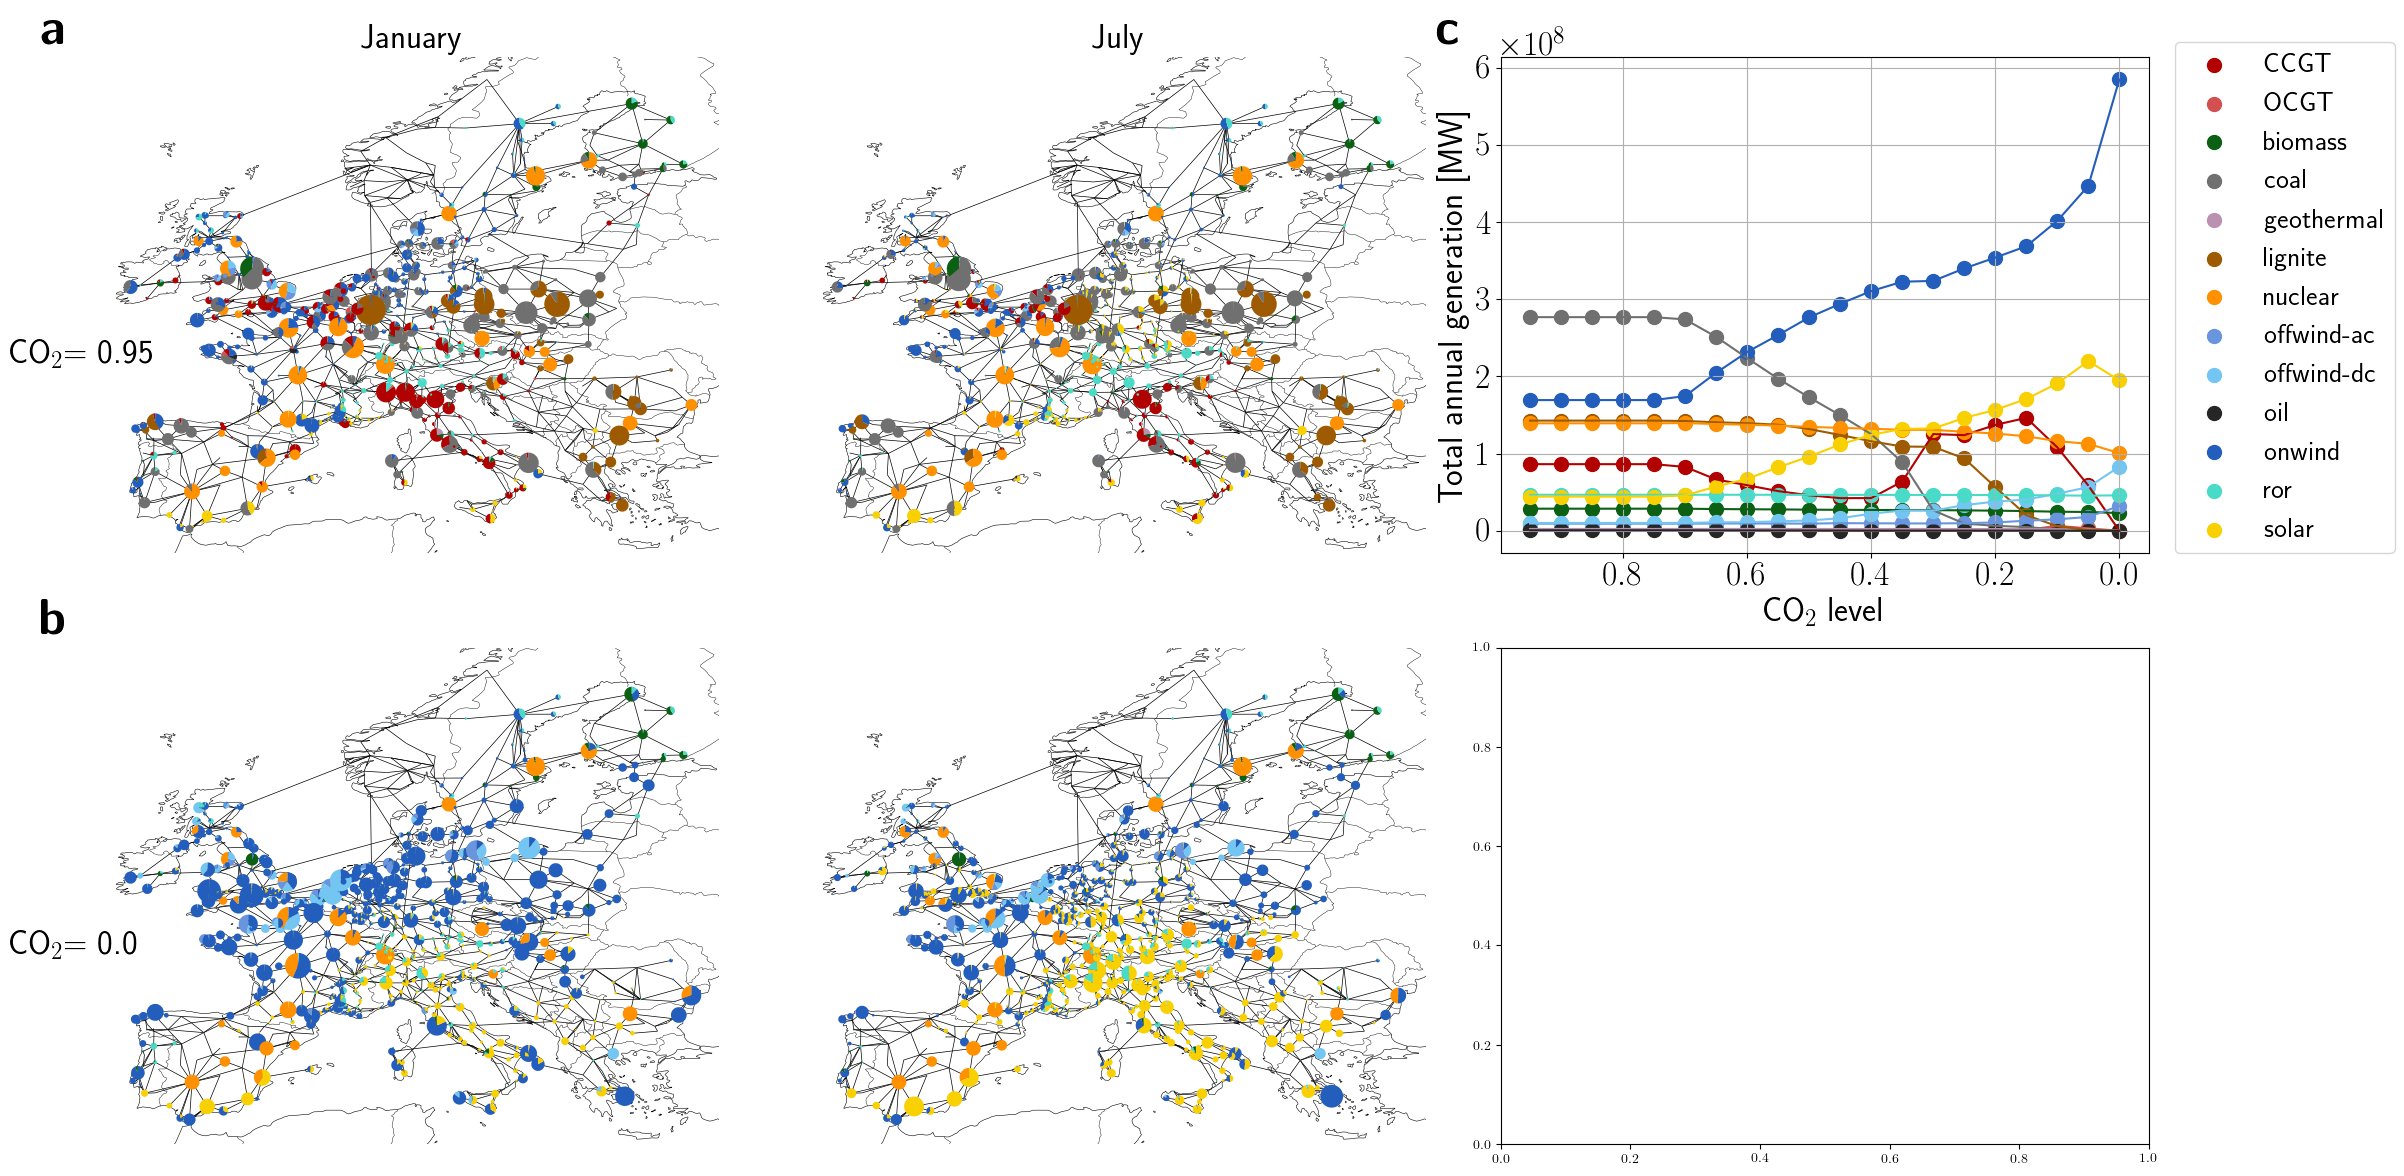

In [4]:
mpl.style.use('default')
plt.rc('text', usetex = True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

target_levels = [0.95,0.0]

f = plt.figure(figsize = (24,12))

gs = GridSpec(2, 3, figure = f)

ax1 = [f.add_subplot(gs[0, i],projection = ccrs.PlateCarree()) for i in range(2)]
ax2 = [f.add_subplot(gs[1, i],projection = ccrs.PlateCarree()) for i in range(2)]
axs = [ax1,ax2]

ax3 = f.add_subplot(gs[0, 2])
ax4 = f.add_subplot(gs[1, 2])

f.subplots_adjust(hspace = 0.05, wspace = 0.05)

#f,ax = plt.subplots(2,3,figsize = (24,12),subplot_kw = {"projection":ccrs.PlateCarree()})
vmax = 3.2e2
months = [1,7]

labels = [[r'\textbf{a}',r'',r'\textbf{c}'],[r'\textbf{b}','',r'\textbf{d}','','']]

for i,ind in enumerate(target_levels):
    n = pypsa.Network()
    n.import_from_netcdf(path_to_pypsa_network+f'elec_s_800_ec_lv1.0_Co2L{ind}-3H.nc')
    
    for j,month in enumerate(months):
        
        axs[i][j].set_ylim([0,vmax])
        current_snapshots = n.snapshots[n.snapshots.month == month]

        
        n.plot(bus_sizes = n.generators_t.p.loc[current_snapshots].sum().groupby([n.generators["bus"],n.generators["carrier"]]).sum()/2e6,
               line_colors = 'black',
               link_colors = 'black', 
               link_widths = 0.5,
               line_widths = 0.5,
               ax = axs[i][j])
        
        
        
        if i == 0:
            axs[i][j].set_title(current_snapshots.month_name()[0], fontsize = 24)
            
        axs[i][j].text(0- 0.1, 1+0.05, 
                         labels[i][j],
                         fontsize = 36,
                         weight = 'bold',
                         verticalalignment = 'center',
                         transform = axs[i][j].transAxes)

        
axs[0][0].text(0- 0.15, 0.4, 
            r'CO$_2$= '+str(0.95),
            fontsize = 24,
            verticalalignment = 'center',
            transform = axs[0][0].transAxes)        

axs[1][0].text(0- 0.15, 0.4, 
            r'CO$_2$= '+str(0.0),
            fontsize = 24,
            verticalalignment = 'center',
            transform = axs[1][0].transAxes)     

##############################     
co2s = generation_by_carrier_and_co2l.columns.astype('float')
index = np.argsort(co2s)

for row in generation_by_carrier_and_co2l.iterrows():
    ax3.scatter(co2s[index],
               (row[1].values)[index],
               color = colors[row[0]],
               label = row[0],
               s = 100)
    
    ax3.plot(co2s[index],
            (row[1].values)[index],
            color = colors[row[0]])
    
ax3.invert_xaxis()
ax3.tick_params(axis = 'both', which = 'both', labelsize = 24)
ax3.set_xlabel(r'$\text{CO}_2 \text{ level}$',  fontsize = 24)
ax3.set_ylabel(r'Total annual generation [MW]', fontsize = 24)

ax3.grid(True)
ax3.yaxis.offsetText.set_fontsize(24)
ax3.text(0- 0.1, 1+0.05, 
                         labels[0][2],
                         fontsize = 36,
                         weight = 'bold',
                         verticalalignment = 'center',
                         transform = ax3.transAxes)
ax3.legend(fontsize = 20,loc=(1.04,0))
#ax3.set_yscale('log')

plt.tight_layout()
#plt.savefig(save_path+'Figures/Generation_mix_versus_co2level.pdf',bbox_inches='tight')

plt.show()

# Figure 3 & Figure 9

In [7]:
co2ls = np.arange(0.0,0.99,0.05)

current_co2ls = co2ls
inertia_time = np.zeros((len(current_co2ls),2920))

for i, co2l in enumerate(current_co2ls):
    
    level = np.round(co2l,2)
    network = pypsa.Network()
    network.import_from_netcdf(path_to_pypsa_network+f'elec_s_800_ec_lv1.0_Co2L{level}-3H.nc')  
    
    inertia_time[i] = utils.calc_system_inertia_over_time(network,snet_index = 0)

/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.0-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this wil

/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.5-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this wil

In [12]:
snet_index = 0

level = 0.0

co2ls = np.arange(0.0,1.0,0.05)

network = pypsa.Network()
network.import_from_netcdf(path_to_pypsa_network+f'elec_s_800_ec_lv1.0_Co2L{np.round(level,2)}-3H.nc')  

G = utils.build_networkx_graph(network,snet_index = snet_index)

target_levels = [0.95,0.00]

inertia_generation = np.zeros((len(target_levels),2,len(G.nodes())))

for j,level in enumerate(target_levels):
    
    ind = np.where(np.round(co2ls,2) == level)[0][0]

    snet_index = 0

    network = pypsa.Network()
    network.import_from_netcdf(path_to_pypsa_network+f'elec_s_800_ec_lv1.0_Co2L{np.round(level,2)}-3H.nc') 

    G = utils.build_networkx_graph(network,snet_index = snet_index)
    pos = nx.get_node_attributes(G,'pos')
    
    indices = np.argsort(inertia_time[ind])
    
    timestamps = [network.snapshots[indices[0]],
                  network.snapshots[indices[-1]]]
    
    load_shedding_indices = network.generators[network.generators.carrier.isin(['load'])].index
    
    for i,timestamp in enumerate(timestamps):
    
        current_generation = network.generators_t.p.loc[timestamp].copy()
        current_generation[load_shedding_indices] /= 1e3
        current_storage    = network.storage_units_t.p.loc[timestamp]
        
        for nodecount,node in enumerate(G.nodes()):
            subgraph = nx.Graph()
            subgraph.add_node(node)
            inertia_generation[j,i,nodecount] = utils.get_inertia_gen_subgraph(subgraph,
                                                              network.generators,
                                                              current_generation,
                                                              network.storage_units,
                                                              current_storage,
                                                               use_pnom = True)

/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.0-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this wil

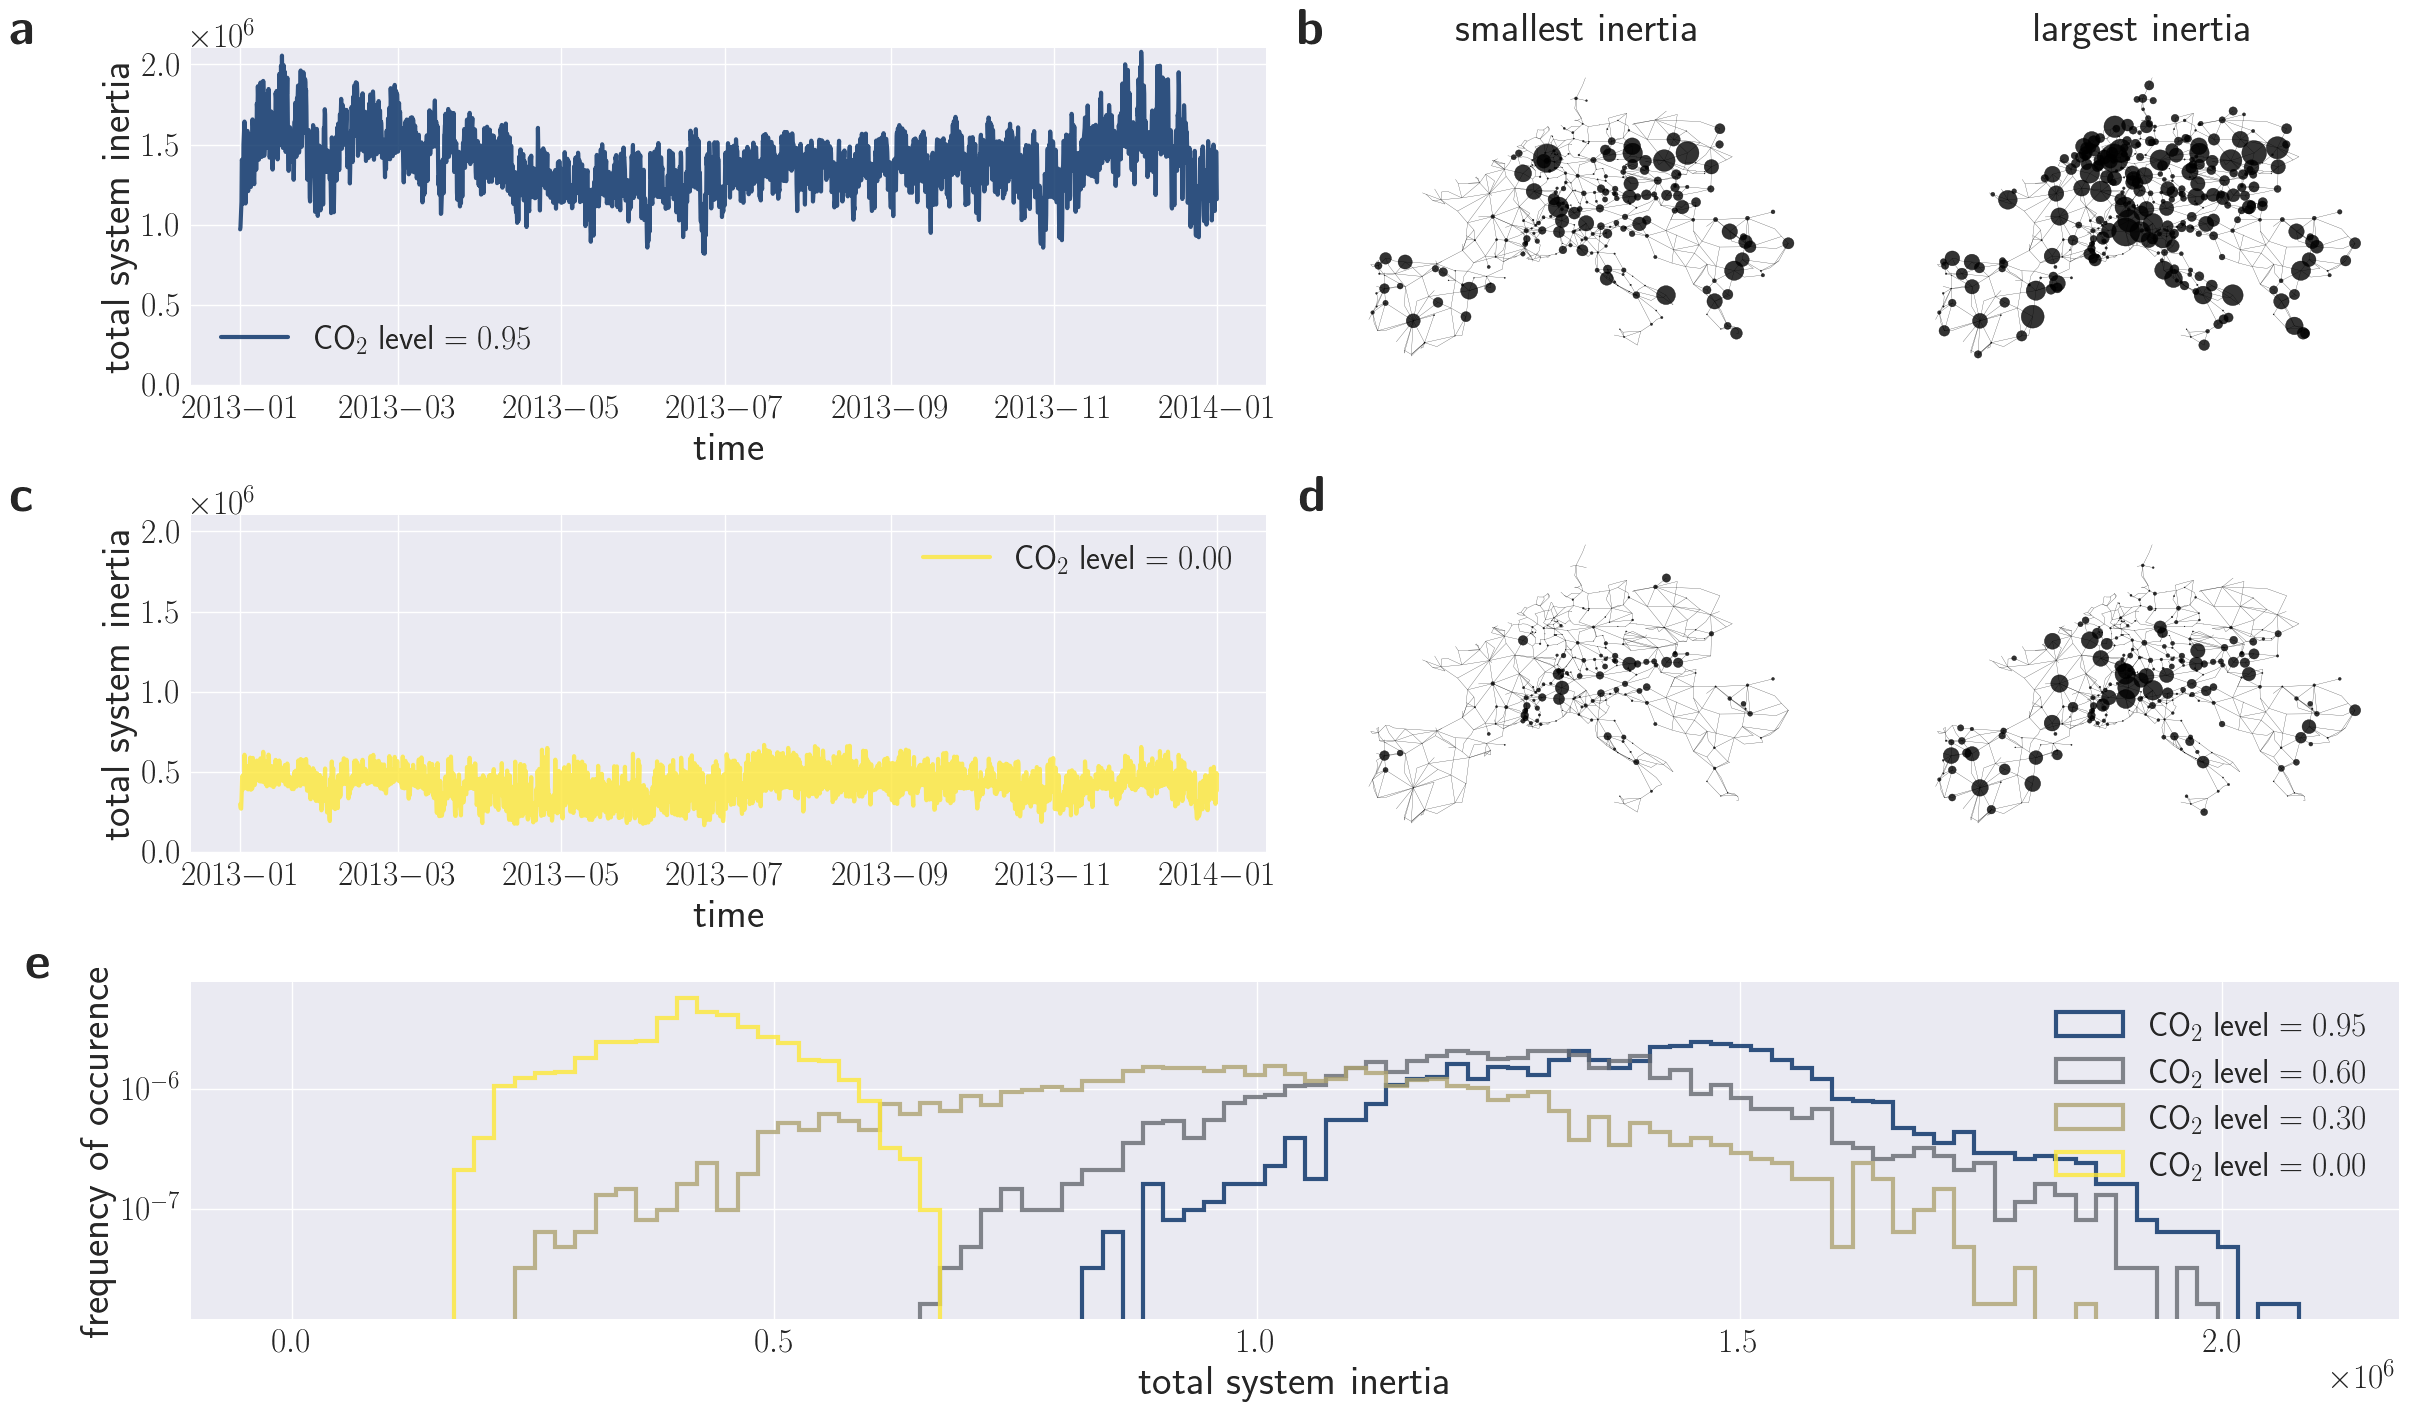

In [13]:
mpl.style.use('seaborn')

plt.rc('text', usetex = True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

labels = [[r'\textbf{a}',r'\textbf{b}'],[r'\textbf{c}',r'\textbf{d}'],[r'\textbf{e}']]

f = plt.figure(figsize = (24,14),constrained_layout = True)

gs = GridSpec(3, 4, figure = f)

ax = f.add_subplot(gs[2, :])
ax2 = f.add_subplot(gs[0, :2])
ax3 = f.add_subplot(gs[1, :2])

ax21 = f.add_subplot(gs[0, 2])
ax22 = f.add_subplot(gs[0, 3])

ax31 = f.add_subplot(gs[1, 2])
ax32 = f.add_subplot(gs[1, 3])

axs = [[ax21,ax22],[ax31,ax32]]

current_co2ls = np.array([0.00,0.3,0.6,0.95])

##################### a )
cmap = plt.get_cmap('cividis_r')

bins = np.arange(0,2.1e6,2.1e4)

for count,level in enumerate(current_co2ls[::-1]):
    
    ind = np.where(np.round(co2ls,2) == level)[0][0]

    ax.hist(inertia_time[ind]*6,
                 bins = bins, 
                histtype='step',
                label = r'$\text{CO}_2\text{ level} = %.2f$'%level,
                linewidth = 3,
            color = cmap(ind/len(co2ls)),
                  density = True,
               alpha = 0.8)   
ax.xaxis.offsetText.set_fontsize(24)
    
ax.legend(fontsize = 24)
ax.tick_params(axis = 'both', which = 'both', labelsize = 24)
ax.set_xlabel('total system inertia',  fontsize = 30)
ax.set_ylabel('frequency of occurence',fontsize = 30)
ax.set_yscale('log')
#ax.set_ylim([0,3.5e5])

#####################################################

axes = [ax2,ax3]

for j,level in enumerate(target_levels):
    
    ind = np.where(np.round(co2ls,2) == level)[0][0]

    axes[j].plot(network.snapshots,
                 inertia_time[ind]*6,
            color = cmap(ind/len(co2ls)),
            lw = 3,
            alpha = 0.8,
            label = r'$\text{CO}_2\text{ level} = %.2f$'%level)
    axes[j].legend(fontsize = 24)
    axes[j].tick_params(axis = 'both', which = 'both', labelsize = 24)
    axes[j].set_ylabel('total system inertia',fontsize = 30)
    axes[j].set_xlabel('time',fontsize = 30)
    axes[j].set_ylim([0,2.1e6])
    axes[j].yaxis.offsetText.set_fontsize(24)


####################################################
snet_index = 0
G = utils.build_networkx_graph(network,snet_index = snet_index)
pos = nx.get_node_attributes(G,'pos')

titles = ['smallest inertia','largest inertia']

for j,level in enumerate(target_levels):
    
    
    for i in range(len(titles)):    
        nx.draw_networkx_nodes(G,
                pos,
                ax = axs[j][i],
                node_size = inertia_generation[j,i]/20, 
                alpha = 0.8,
                node_color = 'black')
        nx.draw_networkx_edges(G,
                pos,
                ax = axs[j][i],
                alpha = 0.8,
                width = 0.2)
        if j==0:
            axs[j][i].set_title(titles[i],fontsize = 30)
        axs[j][i].axis('off')


ax3.text(0- 2.25*0.075, 1+0.05, 
        labels[1][0],
        fontsize = 36,
        weight = 'bold',
        verticalalignment = 'center',
        transform = ax3.transAxes)   

ax2.text(0- 2.25*0.075, 1+0.05, 
        labels[0][0],
        fontsize = 36,
        weight = 'bold',
        verticalalignment = 'center',
        transform = ax2.transAxes)            
 
ax31.text(0- 0.05, 1+0.05, 
        labels[1][1],
        fontsize = 36,
        weight = 'bold',
        verticalalignment = 'center',
        transform = ax31.transAxes)            
ax21.text(0- 0.05, 1+0.05, 
        labels[0][1],
        fontsize = 36,
        weight = 'bold',
        verticalalignment = 'center',
        transform = ax21.transAxes)     


ax.text(0- 0.075, 1+0.05, 
        labels[2][0],
        fontsize = 36,
        weight = 'bold',
        verticalalignment = 'center',
        transform = ax.transAxes)
#plt.savefig(save_path+'Figures/Figure2_total_system_inertia.pdf',bbox_inches = 'tight')
plt.show()

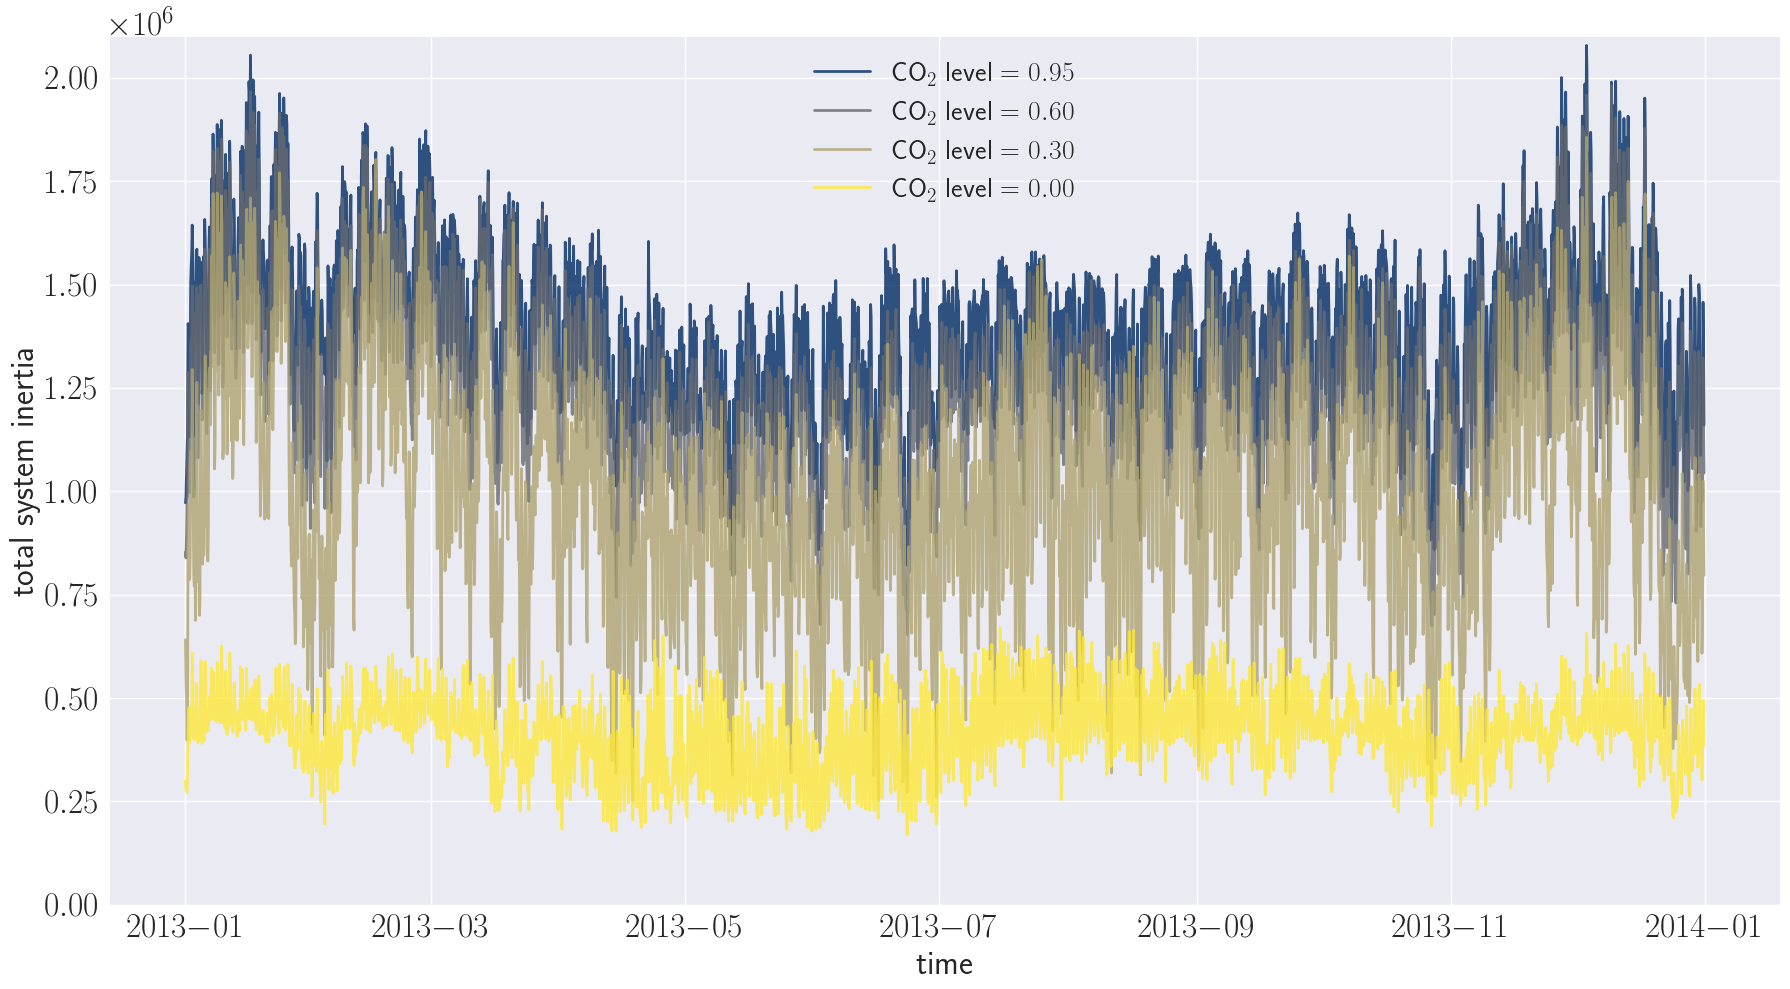

In [14]:
mpl.style.use('seaborn')
f,ax = plt.subplots(figsize=(18,10))
cmap = plt.get_cmap('cividis_r')

co2ls = np.arange(0.0,1.0,0.05)

for count,co2l in enumerate(current_co2ls[::-1]):
    
    ind = np.where(np.round(co2ls,2) == co2l)[0][0]

    ax.plot(network.snapshots,
            inertia_time[ind]*6,
            color = cmap(ind/len(co2ls)),
            lw = 2,
            alpha = 0.8,
            label = r'$\text{CO}_2\text{ level} = %.2f$'%co2l)
    
ax.legend(fontsize = 20)
ax.tick_params(axis = 'both', which = 'both', labelsize = 24)
ax.set_ylabel('total system inertia',fontsize = 24)
ax.set_xlabel('time',fontsize = 24)
ax.yaxis.offsetText.set_fontsize(24)
ax.set_ylim([0,3.5e5*6])
plt.tight_layout()
#plt.savefig(save_path+'Figures/SI_Europe_Total_system_inertia_over_time.pdf',bbox_inches = 'tight')

plt.show()

# Figure 4

In [ ]:
####
####
####
#### calculate dipole vector
####
####
####

snet_index = 0

co2ls = np.arange(0.0,0.99,0.05)

#current_co2ls = co2ls#[0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]#co2ls#

dipole_vector = np.zeros((len(co2ls),2,len(network.snapshots)))

mean_consumption_vector = np.zeros((len(co2ls),len(G.nodes())))
graph_net_mismatch = np.zeros((len(co2ls),len(network.snapshots)))

for i,level in enumerate(co2ls):
    
    network = pypsa.Network()
    level = np.round(level,2)
    network.import_from_netcdf(path_to_pypsa_network+f'elec_s_800_ec_lv1.0_Co2L{level}-3H.nc')  
    
    G = utils.build_networkx_graph(network,snet_index = snet_index)
    pos = nx.get_node_attributes(G,'pos')
    
    ### NOTE: Here, the mean position is subtracted from the coordinates
    position_vector = np.array([pos[n] for n in G.nodes()])
    position_vector[:,1] -= np.mean(position_vector[:,1])
    position_vector[:,0] -= np.mean(position_vector[:,0])    

    #position_vector[:,0] /= np.max(position_vector[:,0])
    #position_vector[:,1] /= np.max(position_vector[:,1])
    #position_vector[:,1] -= np.mean(position_vector[:,1])
    #position_vector[:,0] -= np.mean(position_vector[:,0])
    
    nodal_balance = (network.generators_t.p.T.groupby(network.generators["bus"]).sum()-\
                    network.loads_t.p.T.groupby(network.loads["bus"]).sum()+\
                    network.storage_units_t.p.T.groupby(network.storage_units["bus"]).sum()).copy()
    
    ## add hvdc link subtraction/addition
    nodal_balance = nodal_balance.add(-network.links_t.p0.T.groupby(network.links["bus0"]).sum(), fill_value=0)
    nodal_balance = nodal_balance.add(-network.links_t.p1.T.groupby(network.links["bus1"]).sum(), fill_value=0)
    
    nodal_balance = -nodal_balance
    #total_gen = network.storage_units_t.p.T.sum()+network.generators_t.p.T.sum()
    # 
    #nodal_balance = nodal_balance/total_gen
    
    for nodecount,node in enumerate(G.nodes()):
        mean_consumption_vector[i,nodecount] = nodal_balance.mean(axis = 1).loc[node]
        graph_net_mismatch[i] += nodal_balance.loc[node]
        dipole_vector[i] += np.outer(position_vector[nodecount],nodal_balance.loc[node].to_numpy())
        

/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.0-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this wil

/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))


In [ ]:
### Calculate spatial power inhomogeneity
###
### To calculate the spatial power inhomogeneity (spi) we rescale the spi vector
### by the below scale factor, since it has the units of power and positions in long and lat
### We then evaluate the geodesic distance between the mean position (given in logitude and latitude)
### and the end point of the rescaled spi vector
###
###


co2ls = np.arange(0.0,0.99,0.05)

vec_norm = np.zeros((len(co2ls),len(network.snapshots)))
positions = np.array([pos[n] for n in G.nodes()])
mean_pos = np.array([np.mean(positions[:,0]),np.mean(positions[:,1])])
scale_factor = 5e4

k = gd.Geodesic() 

for i in range(len(co2ls)):
    for j in range((len(network.snapshots))):
        shapely_pos = Point(dipole_vector[i,:,j]/scale_factor+mean_pos)
        distance = k.inverse(shapely_pos, Point(mean_pos)).base[0,0]/1000
        vec_norm[i,j] = distance


In [ ]:
mpl.style.use('default')
plt.rc('text', usetex = True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

labels = [[r'\textbf{a}',r'\textbf{b}'],[r'\textbf{c}',r'\textbf{d}',r'\textbf{e}',r'\textbf{f}']]

f = plt.figure(figsize = (20,12),constrained_layout = True)

current_co2ls = np.array([0.00,0.3,0.6,0.95])

gs = GridSpec(4, 6, figure = f)

ax = f.add_subplot(gs[:2, :3],projection = ccrs.PlateCarree())
ax2 = f.add_subplot(gs[:2, 3:])

axs = [f.add_subplot(gs[2,i],projection = ccrs.PlateCarree()) for i in range(6)]
axs2 = [f.add_subplot(gs[3,i],projection = ccrs.PlateCarree()) for i in range(6)]
axs_both = [axs,axs2]
###############################################

resolution = "50m"
color_geomap = {'ocean': 'lightblue', 'land': 'whitesmoke'}

ax.add_feature(cartopy.feature.LAND.with_scale(resolution),
                    facecolor = color_geomap['land'])
ax.add_feature(cartopy.feature.OCEAN.with_scale(resolution),
                    facecolor = color_geomap['ocean'])

ax.coastlines(linewidth = 0.4, zorder = 2, resolution=resolution)
border = cartopy.feature.BORDERS.with_scale(resolution)
ax.add_feature(border, linewidth=0.3)


cmap = plt.get_cmap('cividis_r')

position_vector = np.array([pos[n] for n in G.nodes()])
mean_pos = [np.mean(position_vector[:,0]),np.mean(position_vector[:,1])]


nx.draw_networkx_edges(G,
                pos,
                ax = ax,
                alpha = 0.8,
                width = 0.2)

scale_factor = 1e4

current_vec = np.mean(dipole_vector,axis = 2)
vec = mean_consumption_vector

plot_co2ls = [0.95]

for i,level in enumerate(plot_co2ls):
    
    ind = np.where(np.round(co2ls,2) == level)[0][0]
    
    node_colours = ['tab:red' if vec[ind,i]<0 else 'tab:blue' for i in range(len(G.nodes()))]
    
    nx.draw_networkx_nodes(G,
            pos,
            ax = ax,
            node_size = np.abs(vec[ind])/10, 
            node_color = node_colours,
            alpha = 0.8 )
    
    ax.arrow(mean_pos[0],
             mean_pos[1],
             current_vec[ind,0]/scale_factor,
             current_vec[ind,1]/scale_factor,
             head_width = 2.0,
             width = 1.0,
             head_length = 2.0,
             #alpha  = .8,
             facecolor = cmap(ind/len(co2ls)))
    ax.axis('off')


##################### a )
#bins = np.arange(0,5e5,5000)
bins = np.arange(0,1e3,10)#np.arange(0,0.08,0.001)#

for i,level in enumerate(current_co2ls[::-1]):
    
    ind = np.where(np.round(co2ls,2) == level)[0][0]
    ax2.hist(vec_norm[ind],
                bins = bins, 
                histtype='step',
                label = r'$\text{CO}_2\text{ level} = %.2f$'%level,
                linewidth = 3,
                color = cmap(ind/len(co2ls)),
                density = True,
                alpha = 0.8)   
ax2.legend(fontsize = 24)
ax2.tick_params(axis = 'both', which = 'both', labelsize = 24)
ax2.set_xlabel(r'$|\mathbf{SPI}(t)|$',fontsize = 30)
ax2.set_ylabel('frequency of occurence',fontsize = 30)
ax2.grid(True)
ax2.yaxis.offsetText.set_fontsize(24)

#####################################################
old_ind = 0

for j in range(12):
    
    xcoord = int(j//6)
    ycoord = int(j%6)
    
    new_ind = old_ind + len(network.snapshots[network.snapshots.month == int(j+1)])

    current_vec = np.mean(dipole_vector[:,:,old_ind:new_ind],axis = 2)

    for i,level in enumerate(current_co2ls):
        ind = np.where(np.round(co2ls,2) == level)[0][0]
    
        axs_both[xcoord][ycoord].arrow(mean_pos[0],
                 mean_pos[1],
                 current_vec[ind,0]/scale_factor,
                 current_vec[ind,1]/scale_factor,
                 head_width = 2.0,
                 width = 1.0,
                 head_length = 2.0,
                 #alpha  = .8,
                 facecolor = cmap(ind/len(co2ls)))
    axs_both[xcoord][ycoord].axis('off')
    lims = axs_both[xcoord][ycoord].get_ylim()
    axs_both[xcoord][ycoord].set_ylim([31.707498915424157,60.29928495567561])
    print(lims)
    
    
    old_ind = new_ind

    #if xcoord == 0:
    #    pos1 = axs_both[xcoord][ycoord].get_position()
    #    pos2 = [pos1.x0, pos1.y0,pos1.width,pos1.height]
    #    axs_both[xcoord][ycoord].set_position(pos2)
####################################################

ax2.text(-0.05, 1+0.05, 
        labels[0][1],
        fontsize = 36,
        weight = 'bold',
        verticalalignment = 'center',
        transform = ax2.transAxes)

ax.text(-0.05, 1+0.05, 
        labels[0][0],
        fontsize = 36,
        weight = 'bold',
        verticalalignment = 'center',
        transform = ax.transAxes)    

axs_both[0][0].text(-0.6, 1+0.3, 
        labels[1][0],
        fontsize = 36,
        weight = 'bold',
        verticalalignment = 'center',
        transform = axs_both[0][0].transAxes)      

ax.set_title(r'$\langle \mathbf{SPI}(t)\rangle_t$', fontsize  = 30) 


for j in range(12):
    xcoord = int(j//6)
    ycoord = int(j%6)   
    axs_both[xcoord][ycoord].set_title(network.snapshots[network.snapshots.month == j+1][0].month_name(),
                                       fontsize = 24,
                                      pad = -500)

#plt.savefig(save_path+'Figures/Figure3_inital_grid_situation.pdf',bbox_inches = 'tight')
plt.show()

# Figure 5

In [ ]:
## load presolved likelihoods. See example notebook "Example_run.ipynb"
## or "Example_visualise_results.py" to see how this is calculated
edge_likelihoods_primary = np.load(save_path+'primary_likelihoods_versus_co2ls.npy')
edge_likelihoods_secondary = np.load(save_path+'secondary_likelihoods_versus_co2ls.npy')

In [ ]:
f = plt.figure(figsize = (24,14))

gs = GridSpec(7, 4, figure = f)

axs = [f.add_subplot(gs[:3, i]) for i in range(4)]
axs2 = [f.add_subplot(gs[3:6, i]) for i in range(4)]

ax0 = f.add_subplot(gs[6, :])

f.subplots_adjust(hspace = -0.1, wspace = 0.0)

mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

cmap = copy.copy(mpl.cm.get_cmap("magma_r"))
cmap.set_under('gainsboro',1.0)

labels = [r'\textbf{a}',r'\textbf{b}',r'\textbf{c}',r'\textbf{d}']


co2ls = np.array([0.00,0.3,0.6,0.95])
all_co2ls = np.arange(0.0,0.99,0.05)

vmaxvals = []
vminvals = []

path_to_pypsa_network   = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/'
results_path = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/Results/'

network = pypsa.Network()
currentlevel = np.round(co2l,2)
network.import_from_netcdf(path_to_pypsa_network+f'elec_s_800_ec_lv1.0_Co2L{currentlevel}-3H.nc') # +year+'/elec_s_306_ec_lv1.0_1H.nc')#

criterion = 'nodes'
snet_index = 0

G = utils.build_networkx_graph(network,snet_index = snet_index)
pos = nx.get_node_attributes(G,'pos')


for count,co2l in enumerate(co2ls[::-1]):
 
    ind = np.where(np.round(all_co2ls,2) == co2l)[0][0]
    
    c_H = edge_likelihoods_primary[ind]

    #print(c_H)
    vmax = 0.66#10**(np.max(c_H[np.logical_and(np.logical_and(~np.isnan(c_H),c_H!=-float("inf")),c_H!=1e5)]))
    vmin = 3.4e-4#10**(np.min(c_H[np.logical_and(~np.isnan(c_H),c_H!=-float("inf"))]))  
   
    
    nodes = nx.draw_networkx_nodes(G, 
                                   pos = pos,
                                   ax = axs[count],
                                   node_color = 'black',
                                   node_size = 0)
    
    edges = nx.draw_networkx_edges(G, 
                                   pos = pos,
                                   ax = axs[count], 
                                   edge_color = c_H,
                                   width = 3.5,
                                   edge_cmap = cmap,
                                   edge_vmin = np.log10(vmin),
                                   edge_vmax = np.log10(vmax))
    
    axs[count].axis('off')   
 

cbar_ax = f.add_axes([0.89, 0.6, 0.005, 0.25])#f.add_axes([0.89, 0.35, 0.005, 0.45])#    
sm = plt.cm.ScalarMappable(cmap = cmap,norm = mplcolors.LogNorm(vmin = vmin,vmax = vmax)) 
cb = f.colorbar(sm,cax = cbar_ax)
cb.ax.tick_params(labelsize = 26, width = 1.0, which = 'both')
axs[3].text(0.9, 0.95, 
               r'$\langle p_{\ell}^{\text{p}}\rangle$',
               fontsize = 25, 
               weight = 'bold',
               verticalalignment = 'center',
               transform = axs[3].transAxes)

    
cmap = copy.copy(mpl.cm.get_cmap("viridis_r"))
cmap.set_under('gainsboro',1.0)

for count,co2l in enumerate(co2ls[::-1]):
    
    ind = np.where(np.round(all_co2ls,2) == co2l)[0][0]

    c_H = edge_likelihoods_secondary[ind]
    c_H = np.array([np.log10(x) if x>1e-8 else -np.inf for x in c_H])
    
    #print(c_H)
    vmax = 3.2e-3#10**(np.max(c_H[np.logical_and(np.logical_and(~np.isnan(c_H),c_H!=-float("inf")),c_H!=1e5)]))
    vmin = 3.38e-7#10**(np.min(c_H[np.logical_and(~np.isnan(c_H),c_H!=-float("inf"))]))  
    vmaxvals.append(vmax)
    vminvals.append(vmin)
    
    
    nodes = nx.draw_networkx_nodes(G, 
                                   pos = pos,
                                   ax = axs2[count],
                                   node_color = 'black',
                                   node_size = 0)
    
    edges = nx.draw_networkx_edges(G, 
                                   pos = pos,
                                   ax = axs2[count], 
                                   edge_color = c_H,
                                   width = 3.5,
                                   edge_cmap = cmap,
                                   edge_vmin = np.log10(vmin),
                                   edge_vmax = np.log10(vmax))
    
    axs2[count].axis('off') 
    
    axs[count].set_title(r'$\text{CO}_2 = %.2f$'%co2l,fontsize = 28)
    axs[count].text(0- 0.075, 1+0.05, 
        labels[count],
        fontsize = 30,
        weight = 'bold',
        verticalalignment = 'center',
        transform = axs[count].transAxes)
    
cbar_ax = f.add_axes([0.89, 0.265, 0.005, 0.25])#f.add_axes([0.89, 0.35, 0.005, 0.45])#    
sm = plt.cm.ScalarMappable(cmap = cmap,norm = mplcolors.LogNorm(vmin = vmin,vmax = vmax)) 
cb = f.colorbar(sm,cax = cbar_ax)
cb.ax.tick_params(labelsize = 26, width = 1.0, which = 'both')
axs2[3].text(0.9, 0.95, 
               r'$\langle p_{\ell}^{\text{s}}\rangle$',
               fontsize = 25, 
               weight = 'bold',
               verticalalignment = 'center',
               transform = axs2[3].transAxes)
print(np.max(vmaxvals),np.min(vminvals))

#######################################################

ax0.scatter(all_co2ls[::-1],
        np.sum(10**edge_likelihoods_primary,axis = 1)[::-1]/len(G.edges()), 
           s = 200,
          alpha = 0.8,
           color = 'black')

ax0.plot(all_co2ls[::-1],
        np.sum(10**edge_likelihoods_primary,axis = 1)[::-1]/len(G.edges()),
        color = 'black')

ax0.tick_params(axis = 'both', which = 'both', labelsize = 26)


ax0.grid()
ax0.set_xlim([0,0.95])
ax0.set_ylim([0.0025,0.0125])
ax0.set_xlabel(r'$\text{CO}_2 \text{ level}$', fontsize = 26)
ax0.set_ylabel(r'$\left\langle \langle p_{\ell}^{\text{p}}\rangle\right\rangle_{\ell}$', fontsize = 26)

#pos1 = ax0.get_position()
#pos2 = [pos1.x0+0.045, pos1.y0,pos1.width*0.9,pos1.height*0.7]
#ax0.set_position(pos2)

ax0.invert_xaxis()

ax0.text(0- 0.085, 
         1+0.1, 
        r'\textbf{e}',
        fontsize = 30,
        weight = 'bold',
        verticalalignment = 'center',
        transform = ax0.transAxes)

#ax0.legend(fontsize = 16)

#plt.savefig(save_path+'Figures/Fig4_likelihoods_Europe.pdf',bbox_inches = 'tight')

plt.show()

In [ ]:
#### indices of links with "interesting" primary failure likelihoods
indices = [601,450,0,460,473]
co2ls = np.arange(0.0,0.99,0.05) # np.array([0.0,0.25,0.5,0.75])

f,ax = plt.subplots(figsize = (8,5))

for index in indices:
    ax.scatter(co2ls,
               10**edge_likelihoods[:,index], 
               s = 100,
              alpha = 0.8,
              label = list(G.edges())[index])
    ax.plot(co2ls,
            10**edge_likelihoods[:,index])

ax.set_yscale('log')
ax.tick_params(axis = 'both', which = 'both', labelsize = 16)
ax.set_xlabel('Co2 level', fontsize = 16)
ax.set_ylabel('probability', 
              fontsize = 16)
ax.grid()

ax.legend(fontsize = 16)

plt.show()

print(np.argmax(edge_likelihoods,axis = 1))

list(G.edges())[index]

# Figure 6

In [ ]:
### read in solved splits to calculate rocof from inertia and load imbalance

criterion = 'nodes'

save_path = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/'

path_to_pypsa_network   = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/'
results_path = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/Results/'

snet_index = 0

RoCoF = []
load_imbalances = []
inertia_proxies = []
stamps = []


co2ls = np.arange(0.0,0.99,0.05)

for count,co2l in enumerate(co2ls):
    RoCoF.append([])
    load_imbalances.append([])
    inertia_proxies.append([])
    stamps.append([])
    
    level = np.round(co2l,2)
    network = pypsa.Network()
    network.import_from_netcdf(path_to_pypsa_network+f'elec_s_800_ec_lv1.0_Co2L{level}-3H.nc')

    
    G = utils.build_networkx_graph(network, snet_index = snet_index)
    
    try: 
        splitting_cascades = pickle.load(open(results_path+
                                            f'system_splits_Co2L{level}.pickle','rb'))
        fname = f'Europe_Co2L{level}_split_evaluation_'+criterion+'_based_snet_%i'%snet_index+'_w_hvdc.pickle'
        solution_dict = pickle.load(open(results_path + fname,'rb'))
    except FileNotFoundError:
        print(f'Europe_Co2L{co2l:.2f}')
        continue
    
    nof_splits = 0

    for key in solution_dict.keys():
        for j in range(len(solution_dict[key]))[1::2]:
            for k in range(len(solution_dict[key][j]['load_imbalance'])):
                RoCoF[count].append(solution_dict[key][j]['load_imbalance'][k]/solution_dict[key][j]['inertia_proxy'][k])
                load_imbalances[count].append(solution_dict[key][j]['load_imbalance'][k])
                inertia_proxies[count].append(solution_dict[key][j]['inertia_proxy'][k])
                stamps[count].append([key,solution_dict[key][int(j-1)]])
                #if ((co2l == 0.5) & (-80<=solution_dict[key][j]['load_imbalance'][k]/solution_dict[key][j]['inertia_proxy'][k]<=-70)):
                #    print(key)
    
            nof_splits += 1    
    RoCoF[count] = (np.array(RoCoF[count])*50/2/6).flatten()


In [ ]:
labels = [r'\textbf{a}',r'\textbf{b}',r'\textbf{c}',r'\textbf{d}',r'\textbf{e}']

mpl.style.use('default')

plt.rc('text', usetex = True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

co2ls = np.arange(0.0,0.99,0.05)

f = plt.figure(figsize = (18,10),constrained_layout = True)

gs = GridSpec(3, 4, figure = f)


ax0 = f.add_subplot(gs[0, :2])
ax1 = f.add_subplot(gs[1, :2])

ax_ins = ax1.inset_axes([0.3, 0.5, 0.25, 0.5])
x1, x2, y1, y2 = 0.0, 6*5000, 0, 0.0003

ax_ins.set_xlim(x1, x2)
ax_ins.set_ylim(y1, y2)

#ax_ins.set_xticklabels('')
ax_ins.set_yticklabels('')


ax2 = f.add_subplot(gs[:2, 2:])
#axs = [f.add_subplot(gs[2,i]) for i in range(4)]


snet_index = 0
cmap = plt.get_cmap('cividis_r')

current_co2ls = np.array([0.00,0.3,0.6,0.95])

for count,level in enumerate(current_co2ls[::-1]):
    
    ind = np.where(np.round(co2ls,2) == level)[0][0]
    
    maxval = int(2e4)#3.5e4
    bins = np.arange(-maxval,maxval,1000)
    #ax[count].hist(RoCoF.flatten(),bins = bins, label = r'$\text{CO}_2\text{ level} = %.1f$'%co2l)#i//2,i%2
    if len(load_imbalances[ind]):
        ax0.hist(load_imbalances[ind],
                            bins = bins, 
                            histtype='step',
                            label = r'$\text{CO}_2\text{ level} = %.2f$'%level,
                  linewidth = 3,
                  color = cmap(ind/len(co2ls)),
                  density = True)
    

        maxval = int(1.8e6)#4e5
        bins = np.arange(0,maxval,24000)
        #bins = np.arange(0,5e3,500)
        ax1.hist(np.array(inertia_proxies[ind])*6,
                            bins = bins, 
                            histtype = 'step',
                            label = r'$\text{CO}_2\text{ level} = %.2f$'%level,
                            linewidth = 3,
                  color = cmap(ind/len(co2ls)),
                 alpha = 0.8,
                  density = True)   
        
        bins = np.arange(0,3e4,3000)
        ax_ins.hist(np.array(inertia_proxies[ind])*6,
                            bins = bins, 
                            histtype = 'step',
                            linewidth = 3,
                  color = cmap(ind/len(co2ls)),
                 alpha = 0.8,
                  density = True) 

        maxval = int(2e2)#4e5
        bins = np.arange(-maxval,maxval,2.5)
        #bins = np.arange(0,5e3,500)
        ax2.hist(RoCoF[ind],
                            bins = bins, 
                            histtype='step',
                            label = r'$\text{CO}_2\text{ level} = %.2f$'%level,
                            linewidth = 3,
                  color = cmap(ind/len(co2ls)),
                 alpha = 0.8,
                  density = True) 

ax2.grid(True)
ax1.grid(True)
ax0.grid(True)
ax_ins.grid(True)

ax0.set_xlabel(r'load imbalance $\Delta P$',
                            fontsize = 24)    
ax1.set_xlabel(r'inertia proxy',
                            fontsize = 24)


#from matplotlib import ticker
#formatter = ticker.ScalarFormatter(useMathText=True)
#formatter.set_scientific(True) 
#ax0.yaxis.set_major_formatter(formatter) 
#ax0.ticklabel_format(useOffset=True)

ax_ins.tick_params(axis = 'both', which = 'both', labelsize = 28)

ax0.tick_params(axis = 'both', which = 'both', labelsize = 28)
#ax0.legend(fontsize=20)
ax1.tick_params(axis = 'both', which = 'both', labelsize = 28)
#ax1.legend(fontsize=20)
ax1.yaxis.offsetText.set_fontsize(24)
ax1.xaxis.offsetText.set_fontsize(24)


################################################

ax2.tick_params(axis = 'both', which = 'both', labelsize = 28)
ax2.legend(fontsize = 20)
ax2.set_xlabel(r'RoCoF',fontsize = 24) 
ax2.set_yscale('log')


ax0.text(0- 0.1, 1+0.1, 
        labels[0],
        fontsize = 36,
        weight = 'bold',
        verticalalignment = 'center',
        transform = ax0.transAxes)

ax1.text(0- 0.1, 1+0.1, 
        labels[1],
        fontsize = 36,
        weight = 'bold',
        verticalalignment = 'center',
        transform = ax1.transAxes)

ax2.text(0- 0.1, 1+0.04, 
        labels[2],
        fontsize = 36,
        weight = 'bold',
        verticalalignment = 'center',
        transform = ax2.transAxes)


#plt.savefig(save_path+'Figures/Fig5_Rocof_and_inertia_proxies.pdf',bbox_inches = 'tight')    

plt.show()

# Figure 7

In [9]:
## Figure 7 relies on the clustering method and is therefore currently
## calculated in the analysis notebook, see e.g. the
## "analyse_component_clusters_kmeans_combined.ipynb" notebook

# Figure 8

In [ ]:
mpl.style.use('default')
plt.rc('text', usetex = True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

target_levels = [0.0,0.40,0.80]

f,ax = plt.subplots(3,2,figsize = (24,24),subplot_kw = {"projection":ccrs.PlateCarree()})
vmax = 3.2e2
months = [1,7]

labels = [[r'\textbf{a}',r'\textbf{b}',r'\textbf{c}'],[r'\textbf{c}','',r'\textbf{d}','','']]

for i,ind in enumerate(target_levels):
    
    n = pypsa.Network()
    n.import_from_netcdf(path_to_pypsa_network+f'elec_s_800_ec_lv1.0_Co2L{ind}-3H.nc')
    
    for j,month in enumerate(months):
        
        ax[i,j].set_ylim([0,vmax])
        current_snapshots = n.snapshots[n.snapshots.month == month]

        
        n.plot(bus_sizes = n.generators_t.p.loc[current_snapshots].sum().groupby([n.generators["bus"],n.generators["carrier"]]).sum()/2e6,
               line_colors = 'black',
               link_colors = 'black', 
               link_widths = 0.5,
               line_widths = 0.5,
               ax = ax[i,j])
        
        
        
        if i == 0:
            ax[i,j].set_title(current_snapshots.month_name()[0], fontsize = 24)
        if j == 0:
            ax[i,j].text(0- 0.1, 1+0.05, 
                         labels[j][i],
                         fontsize = 36,
                         weight = 'bold',
                         verticalalignment = 'center',
                         transform = ax[i,j].transAxes)
            
            ax[i,j].text(0- 0.4, 0.5, 
                        r'CO$_2$ level = '+str(ind),
                        fontsize = 24,
                        verticalalignment = 'center',
                        transform = ax[i,j].transAxes)
plt.tight_layout()
#plt.savefig(save_path+'Figures/SI_Generation_mix_versus_co2level.pdf',bbox_inches='tight')
plt.show()

# Figure 10

In [ ]:
### calculate line flows

bins = np.arange(0,1.0,0.02)

co2ls = np.arange(0.0,1.0,0.2)

hist_vals = np.zeros((len(co2ls),len(bins)-1))

current_co2ls = np.array([0.00,0.3,0.6,0.95])


for count,co2l in enumerate(current_co2ls):

    path_to_pypsa_network   = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/'
    results_path = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/Results/'
    
    network = pypsa.Network()
    currentlevel = np.round(co2l,2)
    network.import_from_netcdf(path_to_pypsa_network+f'elec_s_800_ec_lv1.0_Co2L{currentlevel}-3H.nc')

    snet_index = 0
    
    G = utils.build_networkx_graph(network, snet_index = snet_index)
    
    indices = nx.get_edge_attributes(G, 'line_index')
    line_limits = nx.get_edge_attributes(G, 's_nom')
    
    for e, index_list in tqdm(indices.items()):
        loadings = np.abs(network.lines_t.p0.T.loc[index_list[0]]/line_limits[e])
        current_hist = np.histogram(loadings,bins)[0]
        hist_vals[count] += current_hist
    # for e, index_list in indices.items()}

In [ ]:
xpoints = (bins +(bins[1]-bins[0])/2)[1:]

co2ls = np.arange(0.0,1.0,0.05)

f,ax = plt.subplots(figsize = (12,6))

for count,co2l in enumerate(current_co2ls[::-1]):
    
    ind = np.where(np.round(co2ls,2) == co2l)[0][0]
    
    ax.step(xpoints,
          hist_vals[3-count]/np.sum(hist_vals[3-count]),
            label = r'$\text{CO}_2\text{ level} = %.2f$'%co2l,
            linewidth = 2,
            color = cmap(ind/len(co2ls)),
            alpha = 0.8)   
ax.legend(fontsize = 16)
          #width = (bins[1]-bins[0])/2,
             #label = 'data')
ax.set_xlim([0,0.8])
ax.tick_params(axis = 'both', which = 'both', labelsize = 16)
ax.set_xlabel(r'relative line loading', fontsize = 16)
ax.set_ylabel(r'relative frequency', fontsize = 16)
ax.grid(True)
#ax.set_yscale('log')
#ax.set_ylim([4e-3,1e-1])
#plt.savefig(save_path+'Figures/SI_line_utilization_versus_CO2.pdf',bbox_inches = 'tight')

plt.show()